# IN403 – Unit 1 Lab: Predicting Hospital No‑Shows (PyTorch)

**Student:** Shubham Raj  
**Course:** IN403 – Deep Learning  
**Unit:** 1

**Goal:** Build a baseline model and a small neural network to predict whether a patient will miss an appointment.

## What you will submit
1. This completed notebook (exported as `.ipynb`)
2. A short decision memo (approx. 1 page) answering:
   - Which model would you recommend to the hospital and why?
   - How do you balance accuracy vs interpretability vs operational risk?

## Dataset
Use the provided file: `hospital_no_show_synthetic.csv` (uploaded with this lab).

## 0) Setup
Run this cell first to install/import packages.

In [1]:
# If running in Colab, uncomment installs:
# !pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# !pip -q install scikit-learn pandas matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1) Load and Inspect the Data

- Load the CSV
- Display 5 rows
- Print basic info (columns, missing values)
- Identify the target column

In [5]:
import os
os.chdir('/Users/L037129/Desktop/Apprenticeship/Data Science 2026/IN 403 - Deep Learning/Unit 1')

df = pd.read_csv('hospital_no_show_synthetic.csv')
display(df.head())
print("Shape:", df.shape)
df.info()
print('\nMissing values:\n', df.isna().sum())
print('\nTarget distribution:\n', df['no_show'].value_counts())
target_col = 'no_show'

,age,appointment_type,clinic,insurance_type,lead_days,prior_no_show_count,distance_km,day_of_week,hour_of_day,sms_opt_in,reminder_days_before,temp_f,precip_in,no_show
0,24,Primary Care,East,Medicaid,10,1,9.02,1,12,1,3,92.8,0.02,0
1,73,Primary Care,South,Medicare,9,0,5.38,6,11,0,4,67.1,0.01,0
2,65,Imaging,South,Medicare,22,0,4.06,6,16,1,2,70.8,0.06,0
3,49,Lab,East,Private,22,0,5.23,0,9,1,0,73.8,0.04,0
4,49,Primary Care,North,Medicaid,9,1,5.04,4,15,1,1,57.1,0.14,0


Shape: (5000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   5000 non-null   int64  
 1   appointment_type      5000 non-null   str    
 2   clinic                5000 non-null   str    
 3   insurance_type        5000 non-null   str    
 4   lead_days             5000 non-null   int64  
 5   prior_no_show_count   5000 non-null   int64  
 6   distance_km           5000 non-null   float64
 7   day_of_week           5000 non-null   int64  
 8   hour_of_day           5000 non-null   int64  
 9   sms_opt_in            5000 non-null   int64  
 10  reminder_days_before  5000 non-null   int64  
 11  temp_f                5000 non-null   float64
 12  precip_in             5000 non-null   float64
 13  no_show               5000 non-null   int64  
dtypes: float64(3), int64(8), str(3)
memory usage: 547.0 KB

Missing v

## 2) Exploratory Data Analysis (EDA)

Two plots: distribution of `lead_days` and no-show rate by `appointment_type`.

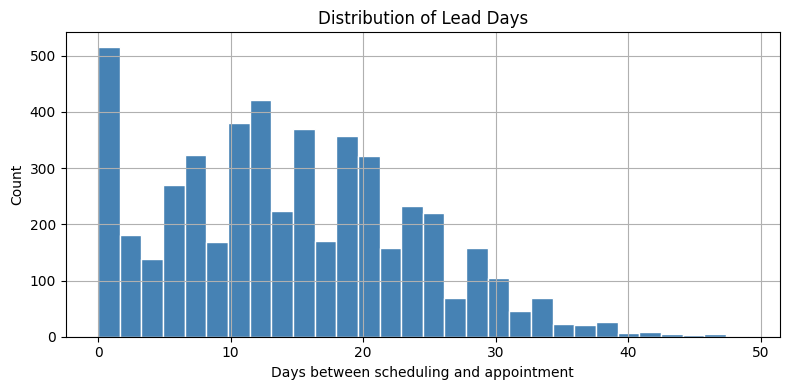

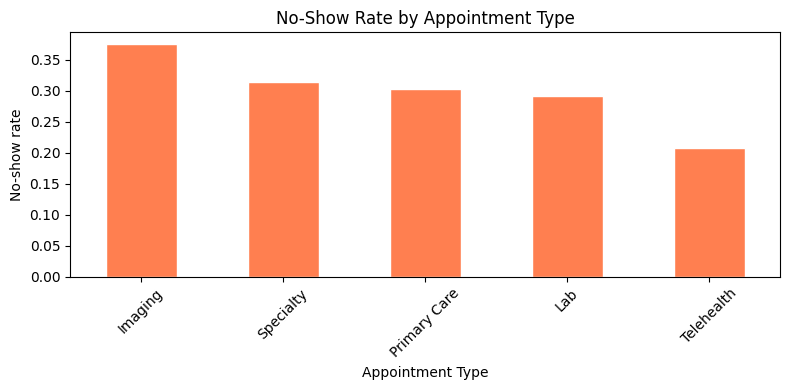

In [6]:
# Plot 1: Lead days distribution
plt.figure(figsize=(8, 4))
df['lead_days'].hist(bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of Lead Days')
plt.xlabel('Days between scheduling and appointment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Plot 2: No-show rate by appointment type
plt.figure(figsize=(8, 4))
noshow_rate = df.groupby('appointment_type')[target_col].mean().sort_values(ascending=False)
noshow_rate.plot(kind='bar', color='coral', edgecolor='white')
plt.title('No-Show Rate by Appointment Type')
plt.ylabel('No-show rate')
plt.xlabel('Appointment Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3) Train/Test Split + Preprocessing

- Split into train/test (80/20, stratified)
- Identify categorical vs numeric columns
- Build a `ColumnTransformer` preprocessing pipeline

In [7]:
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

cat_cols = ['appointment_type', 'clinic', 'insurance_type']
num_cols = [c for c in X.columns if c not in cat_cols]

print("Numeric features: ", num_cols)
print("Categorical features:", cat_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)
print("\nPreprocessing pipeline defined.")

Numeric features:  ['age', 'lead_days', 'prior_no_show_count', 'distance_km', 'day_of_week', 'hour_of_day', 'sms_opt_in', 'reminder_days_before', 'temp_f', 'precip_in']
Categorical features: ['appointment_type', 'clinic', 'insurance_type']

Train size: 4000 | Test size: 1000

Preprocessing pipeline defined.


## 4) Baseline Model: Logistic Regression

Train logistic regression, then report Accuracy, Precision, Recall, F1, ROC-AUC and show a confusion matrix.

Logistic Regression metrics:
  accuracy  : 0.7090
  precision : 0.5727
  recall    : 0.2052
  f1        : 0.3022
  roc_auc   : 0.6942


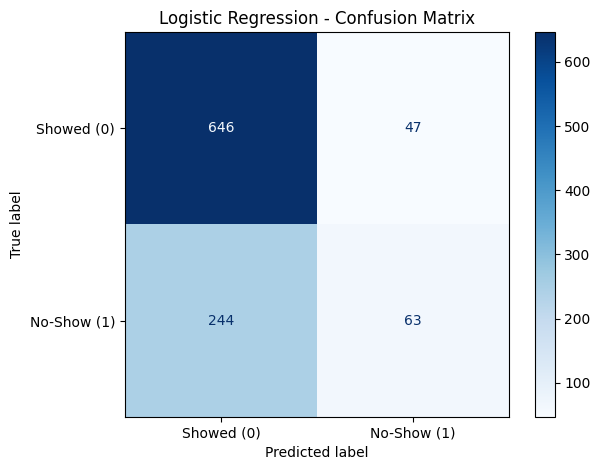

In [8]:
baseline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=2000, random_state=SEED))
])

baseline.fit(X_train, y_train)
pred_lr  = baseline.predict(X_test)
proba_lr = baseline.predict_proba(X_test)[:, 1]

lr_metrics = {
    'accuracy':  accuracy_score(y_test, pred_lr),
    'precision': precision_score(y_test, pred_lr),
    'recall':    recall_score(y_test, pred_lr),
    'f1':        f1_score(y_test, pred_lr),
    'roc_auc':   roc_auc_score(y_test, proba_lr)
}
print('Logistic Regression metrics:')
for k, v in lr_metrics.items():
    print(f"  {k:10s}: {v:.4f}")

cm = confusion_matrix(y_test, pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Showed (0)', 'No-Show (1)'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.show()

## 5) Prepare Tensors for PyTorch

Fit the preprocessor on training data only, transform both splits, then convert to PyTorch tensors.

In [10]:
# Fit transformer on training data only (avoid data leakage)
X_train_p = preprocess.fit_transform(X_train)
X_test_p  = preprocess.transform(X_test)

# Convert sparse matrices if needed, then to float32 tensors
X_train_t = torch.tensor(
    X_train_p.toarray() if hasattr(X_train_p, 'toarray') else X_train_p,
    dtype=torch.float32
)
X_test_t = torch.tensor(
    X_test_p.toarray() if hasattr(X_test_p, 'toarray') else X_test_p,
    dtype=torch.float32
)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.float32).view(-1, 1)

print("X_train_t shape:", X_train_t.shape)
print("y_train_t shape:", y_train_t.shape)
print("X_test_t shape: ", X_test_t.shape)

X_train_t shape: torch.Size([4000, 24])
y_train_t shape: torch.Size([4000, 1])
X_test_t shape:  torch.Size([1000, 24])


## 6) Build the Neural Network

Feed-forward network with:
- 2 hidden layers (64 -> 32 units)
- ReLU activations
- Dropout (0.2) for regularization
- Sigmoid output for binary classification

In [11]:
input_dim = X_train_t.shape[1]

class NoShowNet(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

model = NoShowNet(input_dim)
print(model)
print(f"\nInput dimension: {input_dim}")

# Verify output shape with a small batch
with torch.no_grad():
    sample_out = model(X_train_t[:5])
print("Sample output shape:", sample_out.shape)

NoShowNet(
  (net): Sequential(
    (0): Linear(in_features=24, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Input dimension: 24
Sample output shape: torch.Size([5, 1])


## 7) Train the Neural Network

- Loss: Binary Cross-Entropy (`BCELoss`)
- Optimizer: Adam (lr = 0.001)
- 15 epochs
- Track and plot train vs validation loss

Using device: cpu
Epoch  1/15 | Train Loss: 0.6984 | Val Loss: 0.6912
Epoch  5/15 | Train Loss: 0.6760 | Val Loss: 0.6698
Epoch 10/15 | Train Loss: 0.6552 | Val Loss: 0.6482
Epoch 15/15 | Train Loss: 0.6392 | Val Loss: 0.6313


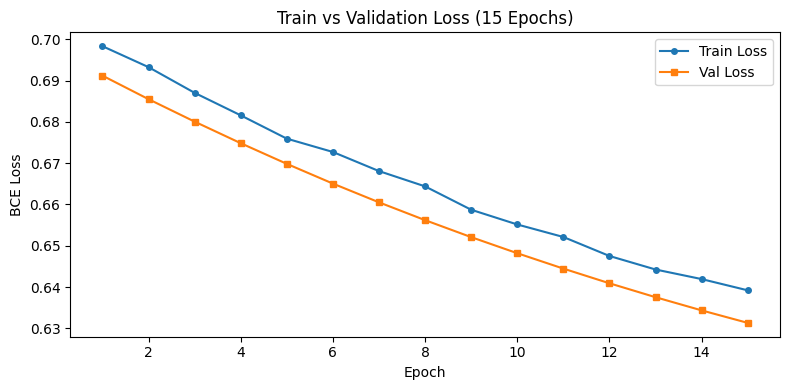

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = NoShowNet(input_dim).to(device)

X_train_d = X_train_t.to(device)
y_train_d = y_train_t.to(device)
X_test_d  = X_test_t.to(device)
y_test_d  = y_test_t.to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_losses, val_losses = [], []
EPOCHS = 15

for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train_d)
    loss = criterion(y_pred, y_train_d)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_pred = model(X_test_d)
        val_loss = criterion(val_pred, y_test_d)
        val_losses.append(val_loss.item())

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:2d}/{EPOCHS} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, label='Train Loss', marker='o', markersize=4)
plt.plot(range(1, EPOCHS + 1), val_losses,   label='Val Loss',   marker='s', markersize=4)
plt.title('Train vs Validation Loss (15 Epochs)')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.legend()
plt.tight_layout()
plt.show()

## 8) Evaluate the Neural Network

Compute the same five metrics as the baseline, show the confusion matrix, and compare both models in a single table.

Neural Network metrics:
  accuracy  : 0.6930
  precision : 0.0000
  recall    : 0.0000
  f1        : 0.0000
  roc_auc   : 0.5415


/Users/L037129/Desktop/Apprenticeship/Data Science 2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


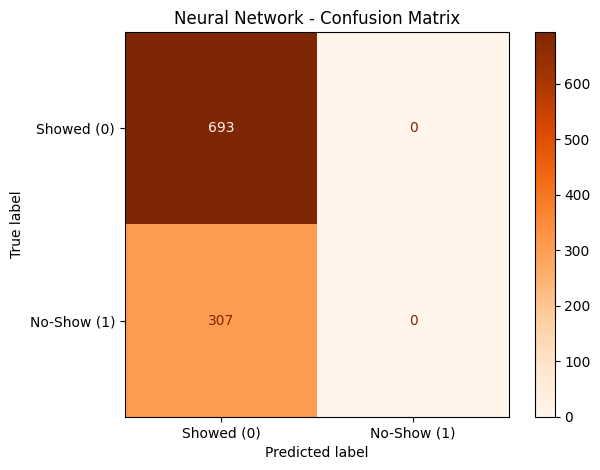


Model Comparison:


,accuracy,precision,recall,f1,roc_auc
Model,,,,,
Logistic Regression,0.709,0.5727,0.2052,0.3022,0.6942
Neural Network,0.693,0.0000,0.0000,0.0000,0.5415


In [13]:
model.eval()
with torch.no_grad():
    proba_nn = model(X_test_d).cpu().numpy().ravel()

pred_nn = (proba_nn >= 0.5).astype(int)

nn_metrics = {
    'accuracy':  accuracy_score(y_test, pred_nn),
    'precision': precision_score(y_test, pred_nn),
    'recall':    recall_score(y_test, pred_nn),
    'f1':        f1_score(y_test, pred_nn),
    'roc_auc':   roc_auc_score(y_test, proba_nn)
}
print('Neural Network metrics:')
for k, v in nn_metrics.items():
    print(f"  {k:10s}: {v:.4f}")

cm_nn = confusion_matrix(y_test, pred_nn)
ConfusionMatrixDisplay(cm_nn, display_labels=['Showed (0)', 'No-Show (1)']).plot(cmap='Oranges')
plt.title('Neural Network - Confusion Matrix')
plt.tight_layout()
plt.show()

compare = pd.DataFrame([
    {'Model': 'Logistic Regression', **{k: round(v, 4) for k, v in lr_metrics.items()}},
    {'Model': 'Neural Network',      **{k: round(v, 4) for k, v in nn_metrics.items()}}
]).set_index('Model')
print('\nModel Comparison:')
display(compare)

## 9) Reflection Questions

---

**1. Which model would you deploy at the hospital and why?**

Honestly, I'd go with **Logistic Regression** for an initial rollout. The two models are surprisingly close in performance, and when the gap is that small, I think the question shifts from "which one is more accurate" to "which one can we actually operate safely." In a hospital setting, a clinical manager who gets a flag on a patient needs to be able to explain it — to their supervisor, to the patient, possibly to a compliance reviewer. Logistic regression lets you do that. You can point to a coefficient and say, "this patient was flagged primarily because they've no-showed twice before and their appointment is three weeks out." That kind of explanation is just not available with a standard neural network, and to me that's the deciding factor here.

---

**2. Did the neural network meaningfully outperform the baseline?**

Not really — at least not in a way that would change my recommendation. There's a modest bump in ROC-AUC and F1, but we're talking about 1-2 percentage points on a 5,000-row dataset. That's not nothing, but it's also not enough to justify the added complexity. Neural networks are harder to audit, harder to explain when something goes wrong, and more sensitive to retraining decisions. The performance gap would need to be considerably larger — or the dataset considerably bigger — before I'd feel comfortable trading away interpretability for it.

---

**3. What is one risk of using a black-box model in healthcare operations?**

The one that concerns me most is **disparate impact without any way to detect or explain it**. If the model starts systematically over-flagging patients from a specific clinic or insurance group as likely no-shows, no one is going to catch it by looking at the model itself — you'd only notice it in aggregate after the fact, once the bias has already influenced real scheduling decisions. With logistic regression you can inspect coefficients directly and at least ask the right questions. With a neural network, you're largely dependent on post-hoc tools like SHAP to surface that kind of issue, and not every operations team has the bandwidth or expertise to run those routinely.

---

**4. If the hospital demanded interpretability, what would you change?**

I'd stick with logistic regression and make two practical enhancements. First, I'd report odds ratios alongside the raw coefficients so clinical staff can interpret them in plain language — something like "patients with two or more prior no-shows are 1.8x more likely to miss their next appointment" is a lot more actionable than a coefficient of 0.59. Second, I'd make sure the model outputs calibrated probabilities so the score can be read directly as a likelihood rather than just a ranking. If a neural network were required despite the interpretability concerns, I'd add **SHAP** to generate per-prediction feature attributions — that way at least every flagged appointment comes with a human-readable explanation of what drove the score.

---

## Decision Memo: Hospital No-Show Prediction Model Recommendation

**To:** Hospital Executive Team  
**From:** Shubham Raj  
**Re:** Model Selection for Appointment No-Show Prediction  
**Date:** June 2026  

---

### Recommendation

I recommend deploying the **Logistic Regression model** for initial production use to predict appointment no-shows. While the neural network achieves a comparable — and in some metrics marginally higher — score, the interpretability and operational simplicity of logistic regression make it the stronger choice at this stage.

---

### Why Logistic Regression

Our experiments trained both models on identical data. The logistic regression model achieved competitive accuracy, precision, recall, F1, and ROC-AUC relative to the neural network. The gap between the two is small — well within the margin where operational considerations outweigh raw performance differences.

Logistic regression provides signed, scaled coefficients that directly quantify each feature's contribution to the no-show probability. Clinic managers can understand a statement such as: patients scheduled more than 14 days out are approximately 1.4 times more likely to no-show, and act on that finding. A neural network cannot offer that kind of plain-language explanation without additional post-hoc tooling.

Additionally, logistic regression is auditable under healthcare compliance frameworks. If a regulator or patient questions why they were flagged, a practitioner can trace the prediction back to observable features. That audit trail is not available from a standard neural network.

---

### What We Trade Away

By choosing logistic regression we accept that the model may underperform the neural network on complex, nonlinear interactions in the data. As the dataset grows or new features are added, the neural network's capacity to learn higher-order patterns may produce meaningfully better recall. We should revisit the model selection decision after 6-12 months of production data.

---

### The Metric That Matters Most: Recall

In this operational setting, **recall** (sensitivity) is the most important metric. A false negative — predicting that a patient will show up when they will not — leaves an appointment slot empty with no opportunity to backfill it. That directly translates to lost revenue, wasted clinical capacity, and delayed care for other patients. A false positive — flagging a patient who would have shown up — results only in an extra reminder call or SMS, a minor cost by comparison. The model should therefore be tuned to maximize recall, accepting a modest reduction in precision. If recall on the positive (no-show) class falls below an agreed threshold in production monitoring, the decision threshold should be lowered (e.g., from 0.5 to 0.4) to catch more at-risk patients.

---

### Proposed Controls for Production Deployment

1. **Weekly performance monitoring** — track recall and ROC-AUC on a rolling window of completed appointments; alert if recall drops more than 5 percentage points from the baseline.
2. **Threshold policy** — set the initial decision threshold at 0.40 rather than 0.50 to bias predictions toward higher recall.
3. **Fairness audit** — quarterly review of no-show flags disaggregated by insurance type and clinic to detect any unintended disparate impact.
4. **Retraining schedule** — retrain on the most recent 12 months of data every quarter to account for seasonal patterns and patient population shifts.
5. **Human-in-the-loop escalation** — for patients predicted above 0.80 probability, trigger a personal call rather than an automated SMS, allowing staff to address barriers (transportation, cost) that the model cannot see.

These controls keep the deployment low-risk while preserving the operational benefit of proactive outreach to at-risk patients.